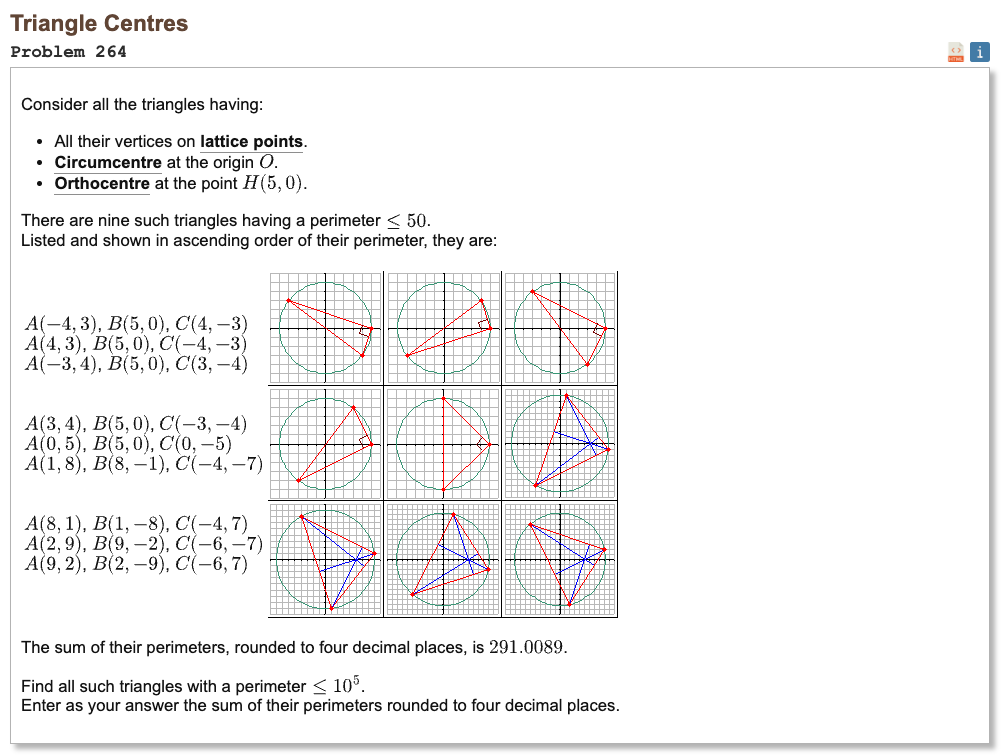

## Initial approach

* Place the circumcentre at (0,0), so all three vertices are integer points at the same distance from the origin.
* Since the orthocentre is (5,0), the sum of the three vertices must be (5,0).
* If we fix the sum of two vertices, the third vertex is automatically determined and all three must still have the same distance from the origin.
* The first two vertices must be placed symmetrically in a way that reduces the check to a simple perfect square condition.
* We generate all valid triangles with perimeter less than 100000, sum their perimeters, and round the result to four decimal places.

In [1]:
import math

def is_square(n: int) -> int:
    if n < 0:
        return -1
    r = int(math.isqrt(n))
    return r if r * r == n else -1

def solve(pmax: int = 100000) -> float:
    rmax = pmax // 3 + 1
    tris = set()
    perim_sum = 0.0

    for g in range(1, rmax + 1):
        r = rmax // g
        if g < 29:
            r = min(r, 40 * g + 10)
        if r <= 0:
            break

        for u0 in range(-r, r + 1):
            for v0 in range(0, r + 1):
                if u0 == 0 and v0 == 0:
                    continue
                if math.gcd(abs(u0), v0) != 1:
                    continue

                s0 = u0 * u0 + v0 * v0
                if s0 == 0 or s0 > r * r:
                    continue

                u = g * u0
                v = g * v0
                s = g * g * s0

                d = 100 - 40 * u + 3 * s
                if d <= 0:
                    continue

                if (u & 1) == 0 and (v & 1) == 0:
                    if d & 3:
                        continue
                    t2 = d // 4
                    if t2 % s0 != 0:
                        continue
                    k2 = t2 // s0
                    k = is_square(k2)
                    if k < 0:
                        continue
                    m = 2 * k
                else:
                    if (u & 1) == 0 or (v & 1) == 0:
                        continue
                    if d % s0 != 0:
                        continue
                    m = is_square(d // s0)
                    if m < 0:
                        continue

                x1n = u - m * v0
                y1n = v + m * u0
                x2n = u + m * v0
                y2n = v - m * u0
                if (x1n & 1) or (y1n & 1) or (x2n & 1) or (y2n & 1):
                    continue

                a = (x1n // 2, y1n // 2)
                b = (x2n // 2, y2n // 2)
                c = (5 - u, -v)

                if a == b or a == c or b == c:
                    continue

                n = a[0] * a[0] + a[1] * a[1]
                if n <= 0:
                    continue
                if b[0] * b[0] + b[1] * b[1] != n:
                    continue
                if c[0] * c[0] + c[1] * c[1] != n:
                    continue

                area2 = a[0] * (b[1] - c[1]) + b[0] * (c[1] - a[1]) + c[0] * (a[1] - b[1])
                if area2 == 0:
                    continue

                def dist(p, q):
                    dx = p[0] - q[0]
                    dy = p[1] - q[1]
                    return math.hypot(dx, dy)

                p = dist(a, b) + dist(b, c) + dist(c, a)
                if p >= pmax:
                    continue

                pts = tuple(sorted((a, b, c)))
                if pts in tris:
                    continue
                tris.add(pts)
                perim_sum += p

    return perim_sum

In [2]:
%%time
solution = solve(100000)
print(f"{solution:.4f}")

2816417.1055
CPU times: user 18 s, sys: 70.3 ms, total: 18.1 s
Wall time: 18.2 s
